In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
from matplotlib import rcParams
from pathlib import Path
import numpy as np

# 设置中文字体支持
import matplotlib.font_manager as fm
# 备选中文字体列表
chinese_fonts = [
    "SimHei",           # Windows
    "Heiti TC",         # macOS
    "WenQuanYi Micro Hei",  # Linux
    "Microsoft YaHei",  # 微软雅黑
    "Arial Unicode MS", # 备选
]

# 获取系统可用字体
available_fonts = {f.name for f in fm.fontManager.ttflist}

# 查找第一个可用的中文字体
for font in chinese_fonts:
    if font in available_fonts:
        plt.rcParams["font.family"] = font
        break

plt.rcParams['axes.unicode_minus'] = False  # 解决负号显示问题

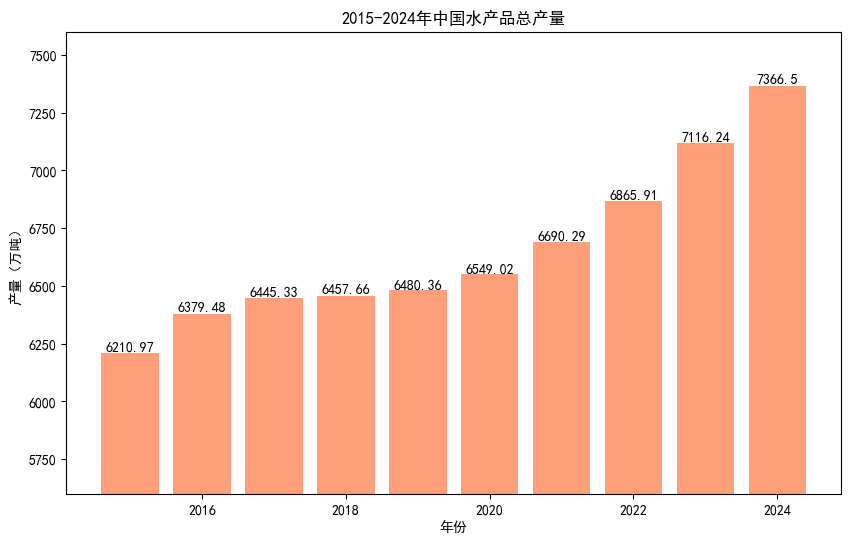

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
from matplotlib import rcParams
from pathlib import Path
import numpy as np

# 年份
years = np.arange(2015, 2025)
# 产量数据（万吨）
outputs = [6210.97, 6379.48, 6445.33, 6457.66, 6480.36, 
           6549.02, 6690.29, 6865.91, 7116.24, 7366.50]

# 创建画布和轴
fig, ax = plt.subplots(figsize=(10, 6))

# 绘制柱状图
bars = ax.bar(years, outputs, color='#FFA07A')  # 设置柱状图颜色

# 添加数值标注
for bar, output in zip(bars, outputs):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width() / 2, height, 
            f'{output}', ha='center', va='bottom')

# 设置标题和坐标轴标签
ax.set_title('2015-2024年中国水产品总产量')
ax.set_xlabel('年份')
ax.set_ylabel('产量（万吨）')

# 设置y轴范围
ax.set_ylim(5600, 7600)  

# 显示图表
plt.show()

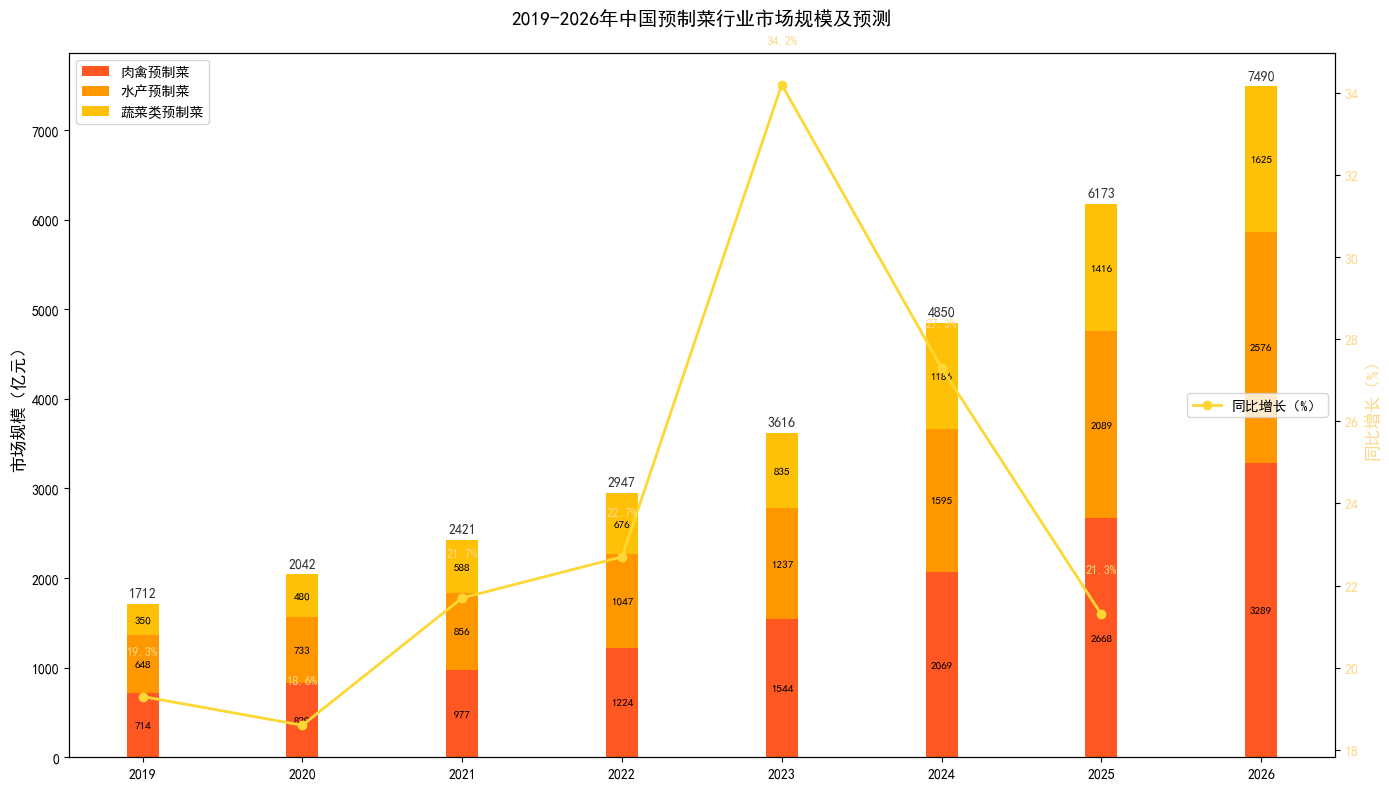

In [6]:
import matplotlib.pyplot as plt
import numpy as np

# 1. 提取图表数据
years = [2019, 2020, 2021, 2022, 2023, 2024, 2025, 2026]
# 各类预制菜市场规模（亿元）
meat = [714, 829, 977, 1224, 1544, 2069, 2668, 3289]        # 肉禽
seafood = [648, 733, 856, 1047, 1237, 1595, 2089, 2576]     # 水产
vegetable = [350, 480, 588, 676, 835, 1186, 1416, 1625]     # 蔬菜
# 总规模（亿元）
total = [1712, 2042, 2421, 2947, 3616, 4850, 6173, 7490]
# 同比增长率（%）
growth = [19.3, 18.6, 21.7, 22.7, 34.2, 27.3, 21.3]

# 2. 绘制组合图表（柱状图+折线图）
x = np.arange(len(years))  # x轴坐标
width = 0.2  # 柱子宽度

fig, ax1 = plt.subplots(figsize=(14, 8))

# 绘制三类预制菜的堆积柱状图
bottom = np.zeros(len(years))
for i, (data, label, color) in enumerate(zip(
    [meat, seafood, vegetable], 
    ['肉禽预制菜', '水产预制菜', '蔬菜类预制菜'], 
    ['#FF5722', '#FF9800', '#FFC107']
)):
    bars = ax1.bar(x, data, width, bottom=bottom, label=label, color=color)
    # 标注各类预制菜的数值
    for j, bar in enumerate(bars):
        height = bar.get_height()
        if height > 50:  # 只标注高度足够的柱子，避免拥挤
            ax1.text(
                bar.get_x() + bar.get_width()/2., 
                bottom[j] + height/2,
                f'{data[j]}',
                ha='center', va='center',
                color='black', fontsize=8
            )
    bottom += data

# 标注总规模数值
for i, val in enumerate(total):
    ax1.text(x[i], total[i] + 80, f'{val}', ha='center', fontsize=10, color='#333')

# 配置左轴（市场规模）
ax1.set_ylabel('市场规模（亿元）', fontsize=12)
ax1.set_xticks(x)
ax1.set_xticklabels(years)
ax1.legend(loc='upper left')

# 新建右轴绘制同比增长率折线
ax2 = ax1.twinx()
ax2.plot(x[:-1], growth, marker='o', color='#FDD835', label='同比增长（%）', linewidth=2)

# 标注增长率数值
for i, val in enumerate(growth):
    ax2.text(x[i], val + 1, f'{val}%', ha='center', fontsize=9, color='#FDD888')

ax2.set_ylabel('同比增长（%）', fontsize=12, color='#FDD888')
ax2.tick_params(axis='y', labelcolor='#FDD888')
ax2.legend(loc='center right')

# 3. 图表整体配置
plt.title('2019-2026年中国预制菜行业市场规模及预测', fontsize=14, pad=20)
plt.tight_layout()
plt.show()

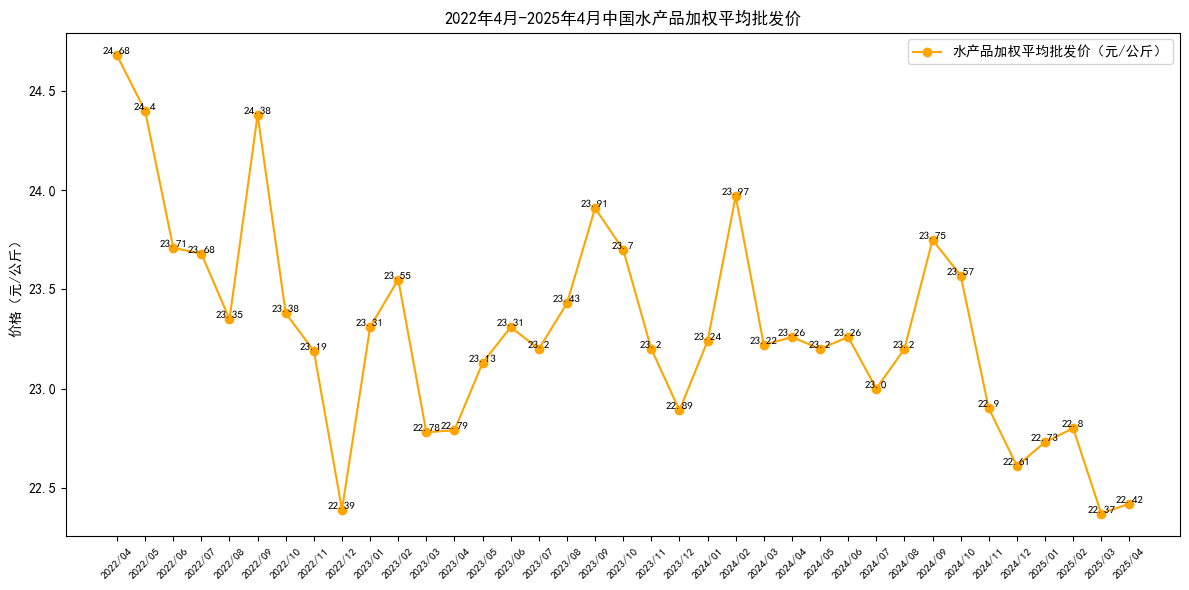

In [5]:
import matplotlib.pyplot as plt
import numpy as np

# 年份月份数据
dates = ["2022/04", "2022/05", "2022/06", "2022/07", "2022/08", "2022/09", "2022/10", "2022/11", "2022/12",
         "2023/01", "2023/02", "2023/03", "2023/04", "2023/05", "2023/06", "2023/07", "2023/08", "2023/09",
         "2023/10", "2023/11", "2023/12", "2024/01", "2024/02", "2024/03", "2024/04", "2024/05", "2024/06",
         "2024/07", "2024/08", "2024/09", "2024/10", "2024/11", "2024/12", "2025/01", "2025/02", "2025/03",
         "2025/04"]
# 对应水产品加权平均批发价（元/公斤）
prices = [24.68, 24.40, 23.71, 23.68, 23.35, 24.38, 23.38, 23.19, 22.39, 23.31, 23.55, 22.78, 22.79, 23.13, 23.31,
          23.20, 23.43, 23.91, 23.70, 23.20, 22.89, 23.24, 23.97, 23.22, 23.26, 23.20, 23.26, 23.00, 23.20, 23.75,
          23.57, 22.90, 22.61, 22.73, 22.80, 22.37, 22.42]

x = np.arange(len(dates))  # x轴坐标

fig, ax = plt.subplots(figsize=(12, 6))
# 绘制折线图
line, = ax.plot(x, prices, marker='o', color='orange', label='水产品加权平均批发价（元/公斤）')

# 添加数值标注
for i, price in enumerate(prices):
    ax.text(x[i], price, f'{price}', ha='center', va='bottom', fontsize=8)

# 设置x轴刻度和标签
ax.set_xticks(x)
ax.set_xticklabels(dates, rotation=45, fontsize=8)
ax.set_ylabel('价格（元/公斤）')
ax.set_title('2022年4月-2025年4月中国水产品加权平均批发价')
ax.legend()

plt.tight_layout()
plt.show()